# Preamble

In [1]:
import os
import numpy as np
from PIL import Image
import pandas as pd
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from torchvision import models
from torchvision.models import ResNet50_Weights
import torch
from torch import nn
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

# Preparing the Data

In [ ]:
image_path = []
labels = []

# Held-out test set: one subfolder per class of images the model never saw.
input_path = 'data/test'


for label in os.listdir(input_path):
    for image in os.listdir(os.path.join(input_path,label)):
        image_path.append(os.path.join(input_path,label,image))
        labels.append(label)

In [3]:
test_df = pd.DataFrame({'image_path':image_path,'label':labels})

print(test_df['label'].unique())

label_encoder = LabelEncoder()
label_encoder.fit(test_df['label'])

['KEK_LAPIS' 'KUIH_KASWI_PANDAN' 'KUIH_KETAYAP' 'KUIH_LAPIS'
 'KUIH_SERI_MUKA' 'KUIH_TALAM' 'KUIH_UBI_KAYU' 'ONDE_ONDE']


LabelEncoder()

In [4]:
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224,224)),
    transforms.ConvertImageDtype(torch.float32),
    # this is the mean and standard deviation for [R,G,B] of the imagenet dataset
    # we can do better normalisation by using the mean and std dev of our
    # dataset
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [5]:
class CustomImageDataset(Dataset):
  def __init__(self, dataframe, transform = None):
    # transform = None initialises default transform as None
    self.dataframe = dataframe
    self.transform = transform
    # transform text labels into numerical labels
    # Keep labels on CPU (do NOT use .to(device) here)
    self.labels = torch.tensor(label_encoder.transform(dataframe["label"]))

  def __getitem__(self, index):
    # iloc[a,b] returns index at [row = a, column = b]
    # note that axis 0 refers to rows and axis 1 refers to columns
    row = self.dataframe.iloc[index]
    img_path = row["image_path"]
    label = self.labels[index]
    image = Image.open(img_path).convert('RGB')
    if self.transform:
      # Keep labels on CPU (do NOT use .to(device) here)
      image = self.transform(image)
    #both image and label on cpu
    return image, label

  def __len__(self):
    #returns how many rows you have in dataframe
    return len(self.dataframe)

In [6]:
test_dataset = CustomImageDataset(test_df, test_transform)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=True)

# Loading the Model

In [7]:
class CustomResNet(nn.Module):
    def __init__(self):
        super(CustomResNet, self).__init__()
        self.resnet = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

#        Freeze ALL RESNET Layers
        # for param in self.resnet.parameters():
        #    param.requires_grad = False
        
#        Freeze layers up to `layer4`
        for name, param in self.resnet.named_parameters():
            if "layer4" not in name:
                param.requires_grad = False 
        
        self.resnet.fc = nn.Identity()
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.Dropout(p=0.44548783592603314),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(p=0.44548783592603314),
            nn.Linear(512, 8)
         )
    def forward(self, x):
        x = self.resnet(x)
        x = self.classifier(x)
        return x

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [ ]:
model = CustomResNet().to(device)
model.load_state_dict(torch.load('models/final_statedict.pt', map_location=device))

In [11]:
# Explanation:
# Precision: Out of all the samples the model predicted as a certain class, how many were actually correct?
# Recall: Out of all the actual samples of a certain class, how many did the model correctly identify?
# F1-Score: The harmonic mean of precision and recall. It balances precision and recall into a single metric.

all_preds = []
all_labels = []
all_probs = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        probs = torch.softmax(outputs, dim = 1)
        _, preds = torch.max(outputs, 1)

        # extend adds each element in the list as a distinct object
        # tensors must be on the cpu to be converted into numpy arrays
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Calculate precision, recall, f1-score for each class
precision = precision_score(all_labels, all_preds, average=None)
recall = recall_score(all_labels, all_preds, average=None)
f1 = f1_score(all_labels, all_preds, average=None)

# If you want macro-average (average across all classes)
macro_precision = precision_score(all_labels, all_preds, average='macro')
macro_recall = recall_score(all_labels, all_preds, average='macro')
macro_f1 = f1_score(all_labels, all_preds, average='macro')

print("Precision per class:", precision)
print("Recall per class:", recall)
print("F1 Score per class:", f1)
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Macro F1 Score:", macro_f1)

Precision per class: [0.97222222 0.94285714 1.         1.         1.         0.94594595
 1.         0.97058824]
Recall per class: [1.         0.94285714 1.         0.97142857 0.97142857 1.
 1.         0.94285714]
F1 Score per class: [0.98591549 0.94285714 1.         0.98550725 0.98550725 0.97222222
 1.         0.95652174]
Macro Precision: 0.9789516932899286
Macro Recall: 0.9785714285714286
Macro F1 Score: 0.9785663862401461


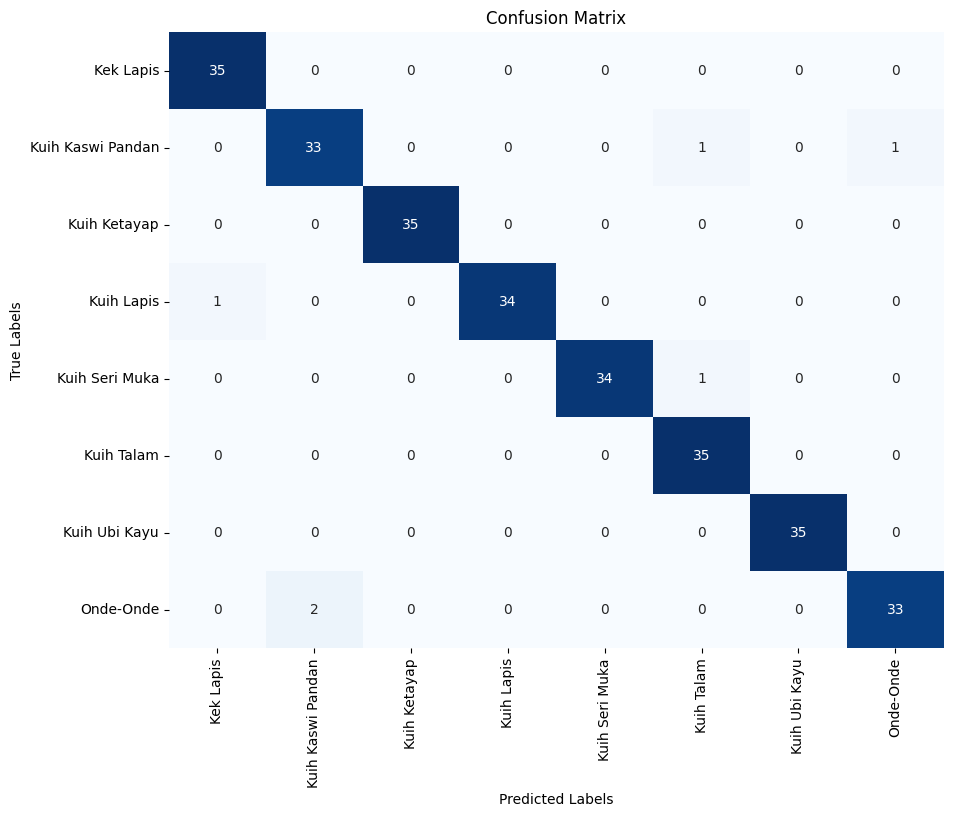

In [14]:
#this returns a two dimensional array of numbers (as written on matrix)
cm = confusion_matrix(all_labels,all_preds)

class_names = ['Kek Lapis', 'Kuih Kaswi Pandan', 'Kuih Ketayap', 'Kuih Lapis', 'Kuih Seri Muka', 'Kuih Talam', 'Kuih Ubi Kayu', 'Onde-Onde']

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.savefig('Confusion_Matrix')
plt.savefig('cm.png')
plt.show()

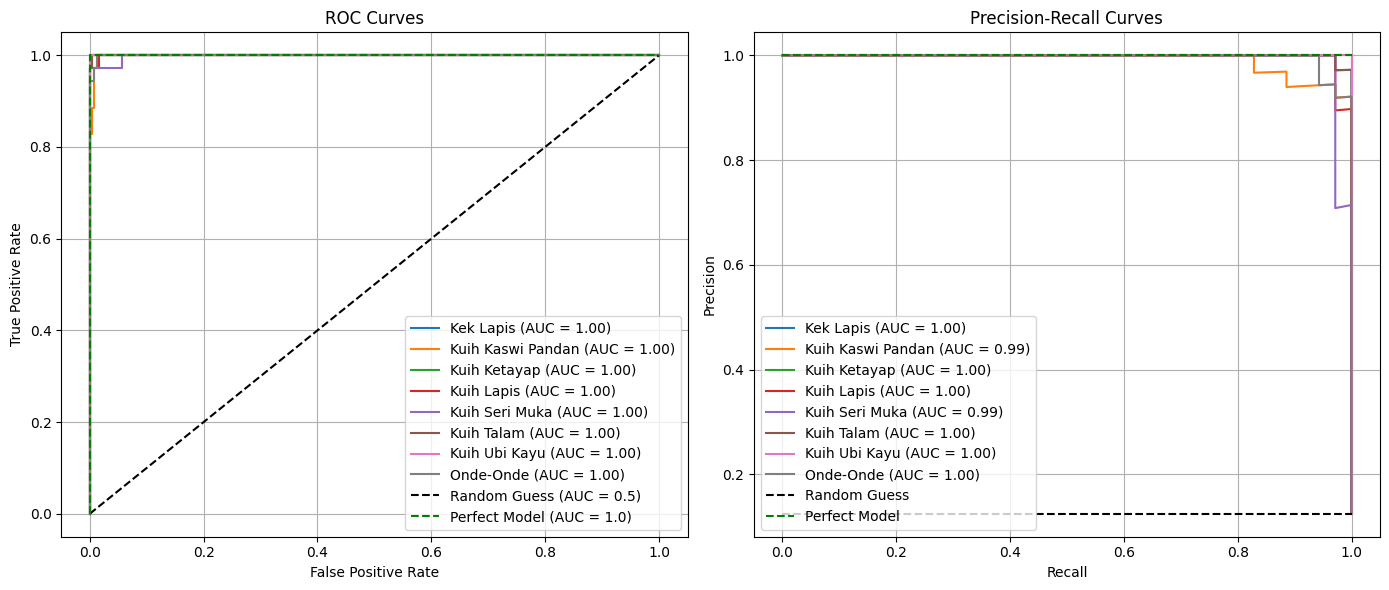

In [15]:
all_labels_arr = np.array(all_labels)
all_preds_arr = np.array(all_preds)
all_probs_arr = np.array(all_probs)

# label_binarize(n,m) returns an array with n arrays of m elements
# n is the number of inputs (images) and m is the number of classes
# the value of the elements is either 1 or 0
# let's say the prediction is index 4, the output will be
# [0,0,0,0,1,0,0,0]
n_classes = len(np.unique(all_labels_arr))
binarized_labels = label_binarize(all_labels_arr, classes=np.arange(n_classes))

# ROC and PRC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
precision = dict()
recall = dict()
prc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(binarized_labels[:, i], all_probs_arr[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

    precision[i], recall[i], _ = precision_recall_curve(binarized_labels[:, i], all_probs_arr[:, i])
    prc_auc[i] = auc(recall[i], precision[i])

# Plot ROC Curves
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

# Plot random guess line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')
# Plot perfect model
plt.plot([0, 0, 1], [0, 1, 1], 'g--', label='Perfect Model (AUC = 1.0)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid()

# Plot PRC Curves
plt.subplot(1, 2, 2)
for i in range(n_classes):
    plt.plot(recall[i], precision[i], label=f'{class_names[i]} (AUC = {prc_auc[i]:.2f})')

# Plot random guess line for PRC (baseline precision)
baseline = sum(all_labels_arr == 1) / len(all_labels_arr)  # Approx baseline for positive class
plt.hlines(y=baseline, xmin=0, xmax=1, colors='k', linestyles='--', label='Random Guess')
# Plot perfect model
plt.plot([0, 1], [1, 1], 'g--', label='Perfect Model')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend()
plt.grid()

plt.tight_layout()

plt.savefig('roc_prc_curves')

plt.show()